# Project 02 - Image Processing

## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

## Function Definitions

In [2]:
def read_img(img_path):
    '''
    Read image from img_path

    Parameters
    ----------
    img_path : str
        Path of image

    Returns
    -------
        Image
    '''

    # YOUR CODE HERE
    img = Image.open(img_path)
    return np.array(img, dtype=np.uint8)


def show_img(img):
    '''
    Show image

    Parameters
    ----------
    img : ndarray
        Image
    '''

    # YOUR CODE HERE
    plt.imshow(img)


def save_img(img, img_path):
    '''
    Save image to img_path

    Parameters
    ----------
    img : ndarray
        Image
    img_path : str
        Path of image
    '''

    # YOUR CODE HERE
    Image.fromarray(img, mode='RGB').save(img_path)


#--------------------------------------------------------------------------------
# YOUR FUNCTIONS HERE
def adjust_brightness(img, brightness):
    '''
    Change the brightness of input image

    Parameters
    ----------
    img : ndarray
        Image
    brightness: int
        Brightness level
    Returns
    -------
        Image with brightness change
    '''
    if brightness < -255 or brightness > 255:
        raise ValueError('Brightness value must be in range [-255;255]')
    
    return np.clip(img.astype(np.int16) + brightness, 0, 255).astype(np.uint8)

def adjust_contrast(img, contrast):
    '''
    Change the contrast of input image

    Parameters
    ----------
    img : ndarray
        Image
    contrast: int
        Contrast level
    Returns
    -------
        Image with contrast change
    '''
    if contrast < -100:
        raise ValueError('Contrast level must not be lower than -100.')

    return np.clip((img.astype(np.int16) - 127) * (1 + contrast / 100) + 127, 0, 255).astype(np.uint8)

def flip_image(img, axis):
    if axis == 0:
        return img[:, ::-1, :] # This syntax result in the array with reverse order along the horizontal axis
    elif axis == 1:
        return img[::-1, :, :] # This syntax result in the array with reverse order along the vertical axis
    else:
        raise Exception('Unknown flip command.')
    
def rgb_to_grayscale(img):
    '''
    Convert input image's color to grayscale

    Parameters
    ----------
    img : ndarray
        Image
    Returns
    -------
        Image in grayscale
    '''
    
    grayscale = np.array([[0.2126, 0.2126, 0.2126],
                          [0.7152, 0.7152, 0.7152],
                          [0.0722, 0.0722, 0.0722]])

    return np.matmul(img, grayscale).astype(np.uint8)

def rgb_to_sepia(img, depth=20, intensity=30):
    '''
    Convert input image's color to sepia

    Parameters
    ----------
    img : ndarray
        Image
    depth: int
        Control the brightness of image after conversion
    intensity: int
        Control the yellowness of image after conversion

    Returns
    -------
        Image in sepia
    '''
    if depth < 0 or intensity < 0:
        raise ValueError('Depth and Intensity should be greater than 0.')

    # Create a grayscale version of image
    grayscale_img = rgb_to_grayscale(img)
    # Construct toning color
    tone = np.array([depth * 2, depth, -intensity])
    
    return np.clip(grayscale_img + tone, 0, 255).astype(np.uint8)

def generate_gaussian_kernel(kernel_size, standard_deviation):
    '''
    Generate a kernel matrix based on input

    Parameters
    ----------
    size: int
        Desired kernel size
    standard_deviation: float
        Standard deviation of Gaussian function
    Returns
    -------
        1D kernel matrix
    '''
    # Auto determine kernel size based on standard deviation
    if kernel_size == 'auto':
        kernel_size = int(standard_deviation * 3) * 2 + 1

    kernel = np.zeros(kernel_size, np.float32)
    m = kernel_size // 2

    # Add kernel value using Gaussian function
    for x in range(kernel_size):
        x1 = np.exp(-((x - m)**2) / (2 * standard_deviation**2))
        x2 = np.sqrt(2 * np.pi * (standard_deviation**2))
        kernel[x] = x1 / x2

    # Return normalized kernel
    return kernel / sum(kernel)

def blur_image(img, kernel_size='auto', standard_deviation=1.):
    '''
    Blur the input image

    Parameters
    ----------
    img : ndarray
        Image
    kernel_size: int
        Desired kernel size
    standard_deviation: float
        Standard deviation of Gaussian function
    Returns
    -------
        Blurred image
    '''
    # Checking parameter constraints
    if kernel_size != 'auto':
        if not isinstance(kernel_size, int):
            raise ValueError('Kernel size must be an integer.')
        if kernel_size <= 1:
            raise ValueError('Kernel size must be greater than 1.')
        if kernel_size % 2 == 0:
            raise ValueError('Kernel size should be an odd number.')

    if standard_deviation < 0.5 or standard_deviation > 100:
        raise ValueError('Standard deviation must be in between 0.5 and 100.')
    
    # Generate kernel
    kernel = generate_gaussian_kernel(kernel_size, standard_deviation)

    # Padding image to fit kernel
    pad_width = kernel.shape[0] // 2
    new_img = np.pad(img, pad_width, mode='edge')
    new_img = new_img[:, :, pad_width: -pad_width]

    # Apply 2 pass of 1d convolution
    new_img = np.apply_along_axis(lambda m: np.convolve(m, kernel, mode='valid'), axis=0, arr=new_img) # convolution along axis X
    new_img = np.apply_along_axis(lambda m: np.convolve(m, kernel, mode='valid'), axis=1, arr=new_img) # convolution along axis Y

    return np.clip(new_img, 0, 255).astype(np.uint8)

def sharpen_image(img, amount=0.5, standard_deviation=1., threshold=0):
    '''
    Sharpen the input image

    Parameters
    ----------
    img : ndarray
        Image
    ammount: float
        Sharpness of image
    standard_deviation: float
        Standard deviation of Gaussian function
    threshold: int
        Threshold of capture sharpen pixels
    Returns
    -------
        Sharpened image
    '''
    # Calculate difference of original image and the blurred one
    if threshold < 0:
        raise ValueError('Threshold must not be less than 0.')

    blur = blur_image(img, 'auto', standard_deviation).astype(np.float32)
    mask = img - blur
    
    # Apply threshold
    if threshold > 0:
        # Calculate level difference of each pixel compared to the original image
        level_diff = np.absolute(np.mean(mask, axis=2))
        pixel_mask = level_diff < threshold
        level_diff[~pixel_mask] = (0)   

        # Construct value for pixel with level difference lower than threshold
        level_diff = np.dstack((level_diff, level_diff, level_diff))
        threshold_map = mask * (255 - threshold) / (threshold - level_diff + 255)

        # Adjust thresholded pixels
        mask[pixel_mask] = threshold_map[pixel_mask]

    return np.clip(img + amount * mask, 0, 255).astype(np.uint8)

def crop_center(img, new_width, new_height):
    '''
    Crop the input image in center

    Parameters
    ----------
    img : ndarray
        Image
    new_width: int
        Width of cropped image
    new_height:
        Height of cropped image
    Returns
    -------
        Cropped image
    '''
    # Get original image size
    height, width, channels = img.shape

    if new_height > height or new_width > width:
        raise ValueError('Crop size must not be greater than original size.')
    if new_width < 1 or new_width < 1:
        raise ValueError('Crop size must be greater than 0.')
    
    # start_width is calculated as (width - new_width) // 2
    # start_height is calculated as (height + new_height) // 2

    return img[(height - new_height) // 2 :(height + new_height) // 2, (width - new_width) // 2:(width + new_width) // 2]

def crop_circle(img):
    '''
    Crop the input image in circle shape in center

    Parameters
    ----------
    img : ndarray
        Image
    Returns
    -------
        Cropped image
    '''
    # Define center coordinate and radius of circle
    height, width, channels = img.shape
    center = (width // 2, height // 2)

    # Determine what dimension is the radius of the circle
    radius = min(width, height) // 2

    # Copy image to new object
    new_img = np.copy(img)

    # Create an array of index
    iY, iX = np.indices(img.shape[:2])

    # Create a mask of index inside shape function
    circle_mask = (iX - center[0])**2 + (iY - center[1])**2 > radius**2

    # Remove pixels outside of shape
    new_img[circle_mask] = (0, 0, 0)

    return new_img

def crop_ellipse(img):
    '''
    Crop the input image in circle shape in center

    Parameters
    ----------
    img : ndarray
        Image
    Returns
    -------
        Cropped image
    '''
    # Define center coordinate, and value for semi-major and semi-minor axis
    height, width, channels = img.shape
    center = (width // 2, height // 2)

    # Determine what dimension is the edge of the square in center
    side = min(width, height)
    
    # Calculate 2 semi- axes's length
    a = 2 * side / 10**0.5
    b = a / 2

    # Set phi = 45 degree or pi / 4 radian
    phi = np.pi / 4

    # Copy image to new object
    new_img = np.copy(img)

    # Create an array of index
    iY, iX = np.indices(img.shape[:2])

    # Create a mask of index inside shape function
    X = (iX - center[0]) * np.cos(phi) + -(iY - center[1]) * np.sin(phi)
    Y = (iX - center[0]) * np.sin(phi) + (iY - center[1]) * np.cos(phi)
    ellipse_mask1 = (X / a)**2 + (Y / b)**2 > 1
    ellipse_mask2 = (Y / a)**2 + (X / b)**2 > 1

    # # Remove pixels outside of shape
    new_img[ellipse_mask1 & ellipse_mask2] = (0,0,0)

    return new_img

def image_scaling(img, scale=2):
    '''
    Scale input image to the designated scale

    Parameters
    ----------
    img : ndarray
        Image
    scale : float
        Proportion of output image to original image
    Returns
    -------
        Scaled Image
    '''
    # Get original image size
    height, width, channels = img.shape

    # If the designated scale is too small stop the scaling
    if width * scale < 1 or height * scale < 1:
        raise ValueError('Image could not be scaled smaller.')
    if scale > 10:
        raise ValueError('Scale is too big.')

    # Get new size from scale
    new_width = int(width * scale)
    new_height = int(height * scale)

    # Create a mask to scale image
    iY, iX = np.indices((new_height, new_width))
    # Assign pixel coordinate of the original image to the mask
    iY, iX = (iY / scale).astype(int), (iX / scale).astype(int)

    if scale < 1:
        return blur_image(img, 'auto', 1 + scale)[iY, iX]
    
    return img[iY, iX]

## Your tests

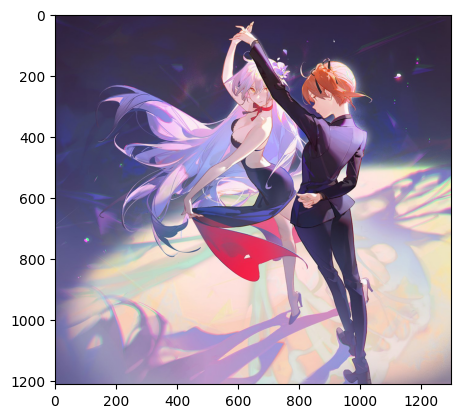

In [3]:
# YOUR CODE HERE
# img_name = '02.jpg'
# img = read_img(img_name)
# show_img(img)

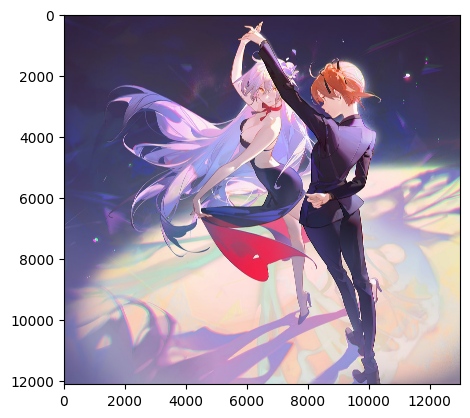

In [4]:
# res = image_scaling(img, 10)
# show_img(res)

## Main FUNCTION

In [3]:
# YOUR CODE HERE
def main():
    # Get file name
    file_name = input('Input image name: ')

    # Read image form file name
    img = read_img(img_path=file_name)


    # Extrace image name
    img_name = file_name.split('.')[-2]

    # Get user's option
    print("Option list: \n1. Adjust brightness.\n2. Adjust contrast\n3. Flip image horizontal/vertical\n4. Converimage to grayscale/sepia\n5. Blur/sharpen image\n6. Crop image by size\n7. Crop image by shape circle/ellipse\n8. Scale image\n0. Do all option")

    option = int(input('Choose opperation from 0 to 8: '))

    # Adjust brightness
    if option == 0 or option == 1:
        res = adjust_brightness(img=img, brightness=20)
        save_img(res, img_name + '_brightness.jpg')

    # Adjust contrast
    if option == 0 or option == 2:
        res = adjust_contrast(img=img, contrast=20)
        save_img(res, img_name + '_contrast.jpg')

    # Flip image
    if option == 0 or option == 3:
        second_option = int(input('Choose flip direction, 0 for horizontal, 1 for vertical: '))
        res = flip_image(img=img, axis=second_option)
        save_img(res, img_name + '_flip.jpg')

    # Convert color
    if option == 0 or option == 4:
        second_option = int(input('Choose conversion type, 0 for grayscale, 1 for seipa: '))
        if second_option == 0:
            res = rgb_to_grayscale(img=img)
            save_img(res, img_name + '_grayscale.jpg')
        elif second_option == 1:
            res = rgb_to_sepia(img=img, depth=20, intensity=30)
            save_img(res, img_name + '_sepia.jpg')
        else:
            raise Exception('Unknown command.')

    # Blur/sharpen image
    if option == 0 or option == 5:
        second_option = int(input('Choose filter type, 0 for blur, 1 for sharpen: '))
        if second_option == 0:
            res = blur_image(img=img, kernel_size='auto', standard_deviation=1.)
            save_img(res, img_name + '_blur.jpg')
        elif second_option == 1:
            res = sharpen_image(img=img, amount=1., standard_deviation=1., threshold=0)
            save_img(res, img_name + '_sharpen.jpg')
        else:
            raise Exception('Unknown command.')

    # Crop image 
    if option == 0 or option == 6:
        res = crop_center(img=img, new_width=512, new_height=512)
        save_img(res, img_name + '_crop.jpg')

    # Crop image by shape
    if option == 0 or option == 7:
        second_option = int(input('Choose crop shape, 0 for circle, 1 for ellipse: '))
        if second_option == 0:
            res = crop_circle(img=img)
            save_img(res, img_name + '_circle.jpg')
        elif second_option == 1:
            res = crop_ellipse(img=img)
            save_img(res, img_name + '_ellipse.jpg')
        else:
            raise Exception('Unknown command.')
        
    # Crop image by shape
    if option == 0 or option == 8:
        res = image_scaling(img=img, scale=2.)
        save_img(res, img_name + '_scale.jpg')


In [5]:
# Call main function
main()

Option list: 
1. Adjust brightness.
2. Adjust contrast
3. Flip image horizontal/vertical
4. Converimage to grayscale/sepia
5. Blur/sharpen image
6. Crop image by size
7. Crop image by shape circle/ellipse
8. Scale image
0. Do all option
